## Loading Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading Data

In [3]:
customer = pd.read_csv('../data/archive/olist_customers_dataset.csv')
orders = pd.read_csv('../data/archive/olist_orders_dataset.csv')
payments = pd.read_csv('../data/archive/olist_order_payments_dataset.csv')
products = pd.read_csv('../data/archive/olist_products_dataset.csv')
order_items = pd.read_csv('../data/archive/olist_order_items_dataset.csv')
reviews = pd.read_csv('../data/archive/olist_order_reviews_dataset.csv')

## Merging Datasets

In [4]:
merged = orders.merge(customer, on = 'customer_id')
merged = merged.merge(payments, on = 'order_id')
merged = merged.merge(order_items, on = 'order_id')
merged = merged.merge(products, on = 'product_id')

## Cleaning Merged Data

In [5]:
merged.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1698
product_name_lenght              1698
product_description_lenght       1698
product_photos_qty               1698
product_weig

### Dropping Nulls

In [6]:
merged = merged.dropna()

In [7]:
merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,128e10d95713541c87cd1a2e48201934,a20e8105f23924cd00833fd87daa0831,delivered,2017-08-15 18:29:31,2017-08-15 20:05:16,2017-08-17 15:28:33,2017-08-18 14:44:43,2017-08-28 00:00:00,3a51803cc0d012c3b5dc8b7528cb05f7,3366,...,29.99,7.78,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
4,0e7e841ddf8f8f2de2bad69267ecfbcf,26c7ac168e1433912a51b924fbd34d34,delivered,2017-08-02 18:24:47,2017-08-02 18:43:15,2017-08-04 17:35:43,2017-08-07 18:30:01,2017-08-15 00:00:00,ef0996a1a279c26e7ecbd737be23d235,2290,...,29.99,7.78,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0


### Convert Dates

In [8]:
merged['order_purchase_timestamp'] = pd.to_datetime(merged['order_purchase_timestamp'])

### Revenue By State

In [9]:
state_revenue = merged.groupby('customer_state')['payment_value'].sum().sort_values(ascending = False)

In [10]:
print(state_revenue.head())

customer_state
SP    7313343.77
RJ    2658069.22
MG    2257861.24
RS    1090171.76
PR    1020152.26
Name: payment_value, dtype: float64


### Viz

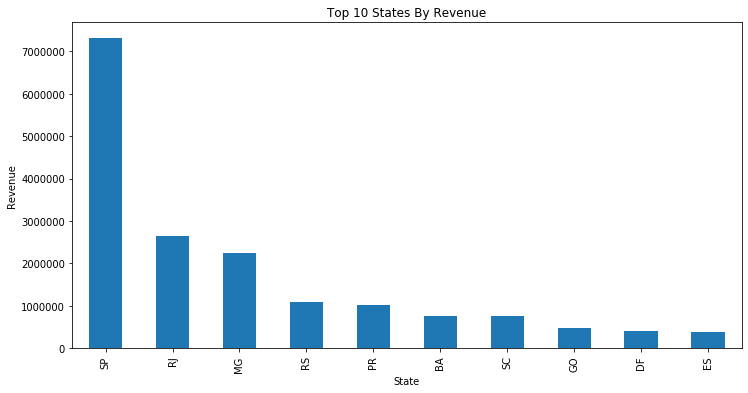

In [11]:
plt.figure(figsize = (12,6))
state_revenue.head(10).plot(kind = 'bar')
plt.title('Top 10 States By Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.show()

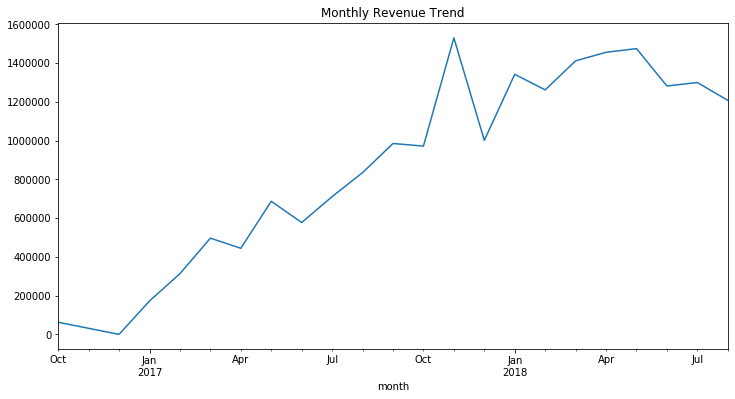

In [12]:
merged['month'] = merged['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = merged.groupby('month')['payment_value'].sum()

monthly_revenue.plot(figsize=(12,6))
plt.title('Monthly Revenue Trend')
plt.show()

In [18]:
customer_summary = merged.groupby('customer_unique_id').agg({'payment_value':'sum','order_id':'nunique'}).reset_index()
customer_summary.columns = ['customer_unique_id','total_spend','total_orders']
customer_summary['segment'] = pd.cut(customer_summary['total_spend'],bins=[0,100,500,1000,100000],labels = ['Low','Medium','High','VIP'])

In [19]:
customer_summary.head()

,customer_unique_id,total_spend,total_orders,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,Medium
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,Low
2,0000f46a3911fa3c0805444483337064,86.22,1,Low
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,Low
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,Medium


In [20]:
final = pd.merge(merged, customer_summary, on = 'customer_unique_id', how = 'inner')

In [21]:
final.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,month,total_spend,total_orders,segment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,2017-10,82.82,2,Low
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,2017-10,82.82,2,Low
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,2017-10,82.82,2,Low
3,69923a4e07ce446644394df37a710286,31f31efcb333fcbad2b1371c8cf0fa84,delivered,2017-09-04 11:26:38,2017-09-04 11:43:25,2017-09-04 21:22:15,2017-09-05 19:20:20,2017-09-15 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2395.0,1.0,350.0,19.0,14.0,12.0,2017-09,82.82,2,Low
4,128e10d95713541c87cd1a2e48201934,a20e8105f23924cd00833fd87daa0831,delivered,2017-08-15 18:29:31,2017-08-15 20:05:16,2017-08-17 15:28:33,2017-08-18 14:44:43,2017-08-28 00:00:00,3a51803cc0d012c3b5dc8b7528cb05f7,3366,...,268.0,4.0,500.0,19.0,8.0,13.0,2017-08,37.77,1,Low


In [22]:
final.groupby('segment').count()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,month,total_spend,total_orders
segment,,,,,,,,,,,,,,,,,,,,,
Low,43446,43446,43446,43446,43446,43446,43446,43446,43446,43446,...,43446,43446,43446,43446,43446,43446,43446,43446,43446,43446
Medium,54478,54478,54478,54478,54478,54478,54478,54478,54478,54478,...,54478,54478,54478,54478,54478,54478,54478,54478,54478,54478
High,8710,8710,8710,8710,8710,8710,8710,8710,8710,8710,...,8710,8710,8710,8710,8710,8710,8710,8710,8710,8710
VIP,6748,6748,6748,6748,6748,6748,6748,6748,6748,6748,...,6748,6748,6748,6748,6748,6748,6748,6748,6748,6748


## Exporting to CSV

In [23]:
final.to_csv('../data/final_tableau_dataset.csv',index=False)